<a href="https://colab.research.google.com/github/ShreyaSP276/Audio_Sentiment_Classification_PG06_Project_2026/blob/main/New_PG06_Project_Audio_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SENTIMENT ANALYSIS WITH PRE_TRAINED TRANSFORMERS

In [ ]:
#Import required libraries for pytorch, huggingface and result evaluation
!pip install transformers
import torch
from transformers import RobertaModel

#libraries for data processingimport pandas as pd
import numpy as np
import pandas as pd


# To plot outputs and visual results
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!pip install h5py validators tqdm requests datasets librosa soundfile

In [ ]:
import os
!pip install torchaudio torchcodec

In [ ]:
import os


In [ ]:
!pip -q install evaluate

**PART 1: Data loading and preprocessing**

In [ ]:
from datasets import load_dataset, Audio
#import pre-hosted dataset instead of manual download
dataset = load_dataset("mteb/crema-d")



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
# check that the frequency is 16HZ, requirement for the model input
dataset = dataset.cast_column("audio", Audio(sampling_rate=16000, decode=False))

In [ ]:
#checking one column
print(dataset['train'][0])

{'audio': {'bytes': b'RIFF\x96\x1c\x01\x00WAVEfmt \x10\x00\x00\x00\x01\x00\x01\x00\x80>\x00\x00\x00}\x00\x00\x02\x00\x10\x00datar\x1c\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x0

In [ ]:
# checking after casting
print(dataset["train"][0]["audio"] )

{'bytes': b'RIFF\x96\x1c\x01\x00WAVEfmt \x10\x00\x00\x00\x01\x00\x01\x00\x80>\x00\x00\x00}\x00\x00\x02\x00\x10\x00datar\x1c\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\

In [ ]:
df = dataset["train"].to_pandas()

df.head()

,audio,label
0,{'bytes': b'RIFF\x96\x1c\x01\x00WAVEfmt \x10\x...,0
1,{'bytes': b'RIFF\x0c\xf2\x00\x00WAVEfmt \x10\x...,0
2,{'bytes': b'RIFF\xbc\x02\x01\x00WAVEfmt \x10\x...,0
3,{'bytes': b'RIFF\xa2I\x01\x00WAVEfmt \x10\x00\...,0
4,{'bytes': b'RIFF\x12\x0b\x01\x00WAVEfmt \x10\x...,0


In [ ]:
#decode audio
import io
import soundfile as sf

def decode_bytes(audio_dict):
    data, samplerate = sf.read(io.BytesIO(audio_dict['bytes']))
    return data
df['audio_array'] = df['audio'].apply(decode_bytes)

PART 2: Exploratory Data Analysis

In [ ]:
#filter data so only 3 classes are used happy =3 , neutral=4, sad =5

#df_filtered['audio_array'] = df['audio'].apply(lambda x: x['array'])

df_filtered = df[df['label'].isin([3,4,5])].reset_index(drop=True)

X = df_filtered.drop(columns=['label'])




In [ ]:
#check dataframe again
df.head()

,audio,label,audio_array
0,{'bytes': b'RIFF\x96\x1c\x01\x00WAVEfmt \x10\x...,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,{'bytes': b'RIFF\x0c\xf2\x00\x00WAVEfmt \x10\x...,0,"[-3.0517578125e-05, -0.000640869140625, 0.0003..."
2,{'bytes': b'RIFF\xbc\x02\x01\x00WAVEfmt \x10\x...,0,"[-0.001434326171875, 0.000274658203125, 0.0006..."
3,{'bytes': b'RIFF\xa2I\x01\x00WAVEfmt \x10\x00\...,0,"[0.003387451171875, 0.003662109375, 0.00381469..."
4,{'bytes': b'RIFF\x12\x0b\x01\x00WAVEfmt \x10\x...,0,"[-0.001068115234375, -0.00152587890625, -0.002..."


In [ ]:
# remap labels 3,4,5 to 0,1,2 : since other numbers are now not being used
mapping = {3: 0, 4: 1, 5: 2}
df_filtered['label'] = df_filtered['label'].map(mapping)

In [ ]:
df_filtered.shape
print(df_filtered.shape[0])

3629


<Axes: xlabel='label', ylabel='count'>

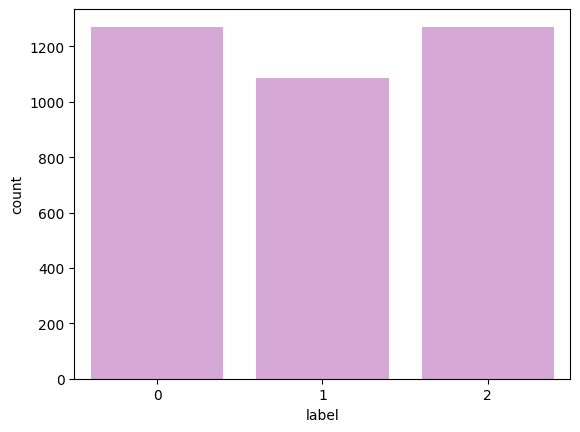

In [ ]:
# plot the data to see if all the labels are balanced
count_plot = df_filtered.groupby(by=['label']).size().reset_index(name='count')
sns.countplot(x=df_filtered['label'], color="plum")



In [ ]:
#Since the neutral label has fewer samples, remove some from the positive and negative to make it more balanced

# Create dataframes with only positive, negative and neutral labels
df_happy=df_filtered[df_filtered['label']==0]
print(df_happy.shape)
df_neutral=df_filtered[df_filtered['label']==1]
print(df_neutral.shape)
df_sad=df_filtered[df_filtered['label']==2]
print(df_sad.shape)

#downsample positive and negative to match the neutral reviews
# use random state to sample the sample way each time the code is run
df_happy_equal=df_happy.sample(df_neutral.shape[0], random_state=42).reset_index(drop=True)
print(df_happy_equal.shape)
df_sad_equal=df_sad.sample(df_neutral.shape[0], random_state=42).reset_index(drop=True)
print(df_sad_equal.shape)


(1271, 3)
(1087, 3)
(1271, 3)
(1087, 3)
(1087, 3)


In [ ]:
#concatenate the dataframes again
df_final=pd.concat([df_happy_equal,df_neutral, df_sad_equal],axis=0).reset_index(drop=True)
df_final.shape

(3261, 3)

<Axes: xlabel='label', ylabel='count'>

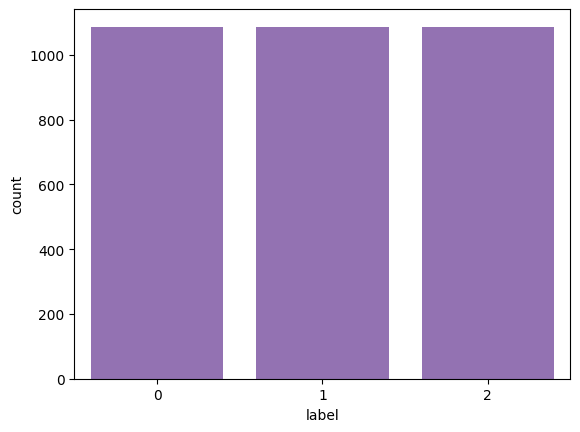

In [ ]:
# print the balanced result
count_plot = df_final.groupby(by=['label']).size().reset_index(name='count')
sns.countplot(x=df_final['label'], color='tab:purple')

<Axes: xlabel='Audio Sample Duration', ylabel='Count'>

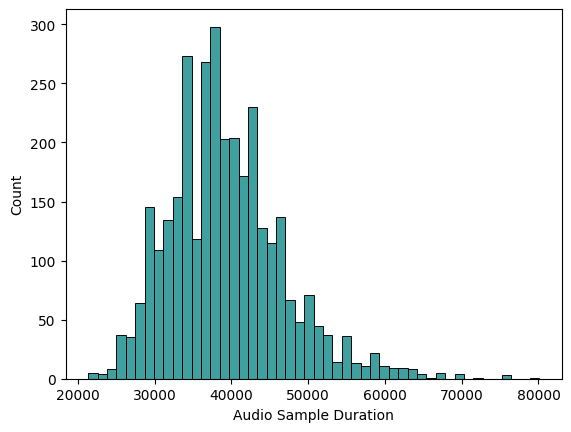

In [ ]:
#check length of audio to find outliers
df_final["Audio Sample Duration"] = df_final['audio_array'].apply(lambda x: len(x) )
sns.histplot(data=df_final, x="Audio Sample Duration", color="teal")

In [ ]:
#truncate the values or pad to have more equal lengths
MAX_LENGTH = 70000 #decided based on histogram

"""def pad_to_max(waveform, max_length):
    pad_len = max_length - len(waveform)
    if pad_len > 0:
        waveform = np.pad(waveform, (0, pad_len))
    return waveform

X = np.stack([pad_to_max(x, max_length) for x in df_final['audio_array']])
y = df_final['label'].to_numpy() """

"def pad_to_max(waveform, max_length):\n    pad_len = max_length - len(waveform)\n    if pad_len > 0:\n        waveform = np.pad(waveform, (0, pad_len))\n    return waveform\n\nX = np.stack([pad_to_max(x, max_length) for x in df_final['audio_array']])\ny = df_final['label'].to_numpy() "

In [ ]:
#remove extra column after data exploration is over
#df = df.drop(columns=["audio_array"])

TRAIN, TEST, SPLIT OF THE CODE

In [ ]:
# 80% of the data is randomly sampled for training
print(df_final.shape)
from sklearn.model_selection import train_test_split

df_combined, df_test = train_test_split(
    df_final,
    test_size=0.1,
    #every label proportion should be preserved in all the splits
    stratify=df_final['label'],
    random_state=42
)

#split the training set into training and validation sets (20 % validation)
df_train, df_val = train_test_split(
    df_combined,
    test_size=0.2,
    stratify=df_combined['label'],
    random_state=42 )


(3261, 4)


In [ ]:
#not currently used method of converted dataset into batches for model
"""from datasets import Dataset

train_dataset = Dataset.from_pandas(df_train, preserve_index=False)
val_dataset  = Dataset.from_pandas(df_val, preserve_index=False)

def preprocess(batch):
    out = feature_extractor(
        batch["audio"],
        sampling_rate=16_000,
        truncation=True,
        max_length=MAX_LENGTH

    )
    out["labels"] = batch["label"]
    return out

train_dataset = train_dataset.map(preprocess, remove_columns=["audio_array", "label"])
val_dataset  = val_dataset.map(preprocess, remove_columns=["audio_array", "label"])"""

'from datasets import Dataset\n\ntrain_dataset = Dataset.from_pandas(df_train, preserve_index=False)\nval_dataset  = Dataset.from_pandas(df_val, preserve_index=False)\n\ndef preprocess(batch):\n    out = feature_extractor(\n        batch["audio"],\n        sampling_rate=16_000,\n        truncation=True,\n        max_length=MAX_LENGTH\n\n    )\n    out["labels"] = batch["label"]\n    return out\n\ntrain_dataset = train_dataset.map(preprocess, remove_columns=["audio_array", "label"])\nval_dataset  = val_dataset.map(preprocess, remove_columns=["audio_array", "label"])'

In [ ]:
#converting into input required by model trainer
from datasets import Dataset

train_dataset = Dataset.from_pandas(df_train[["audio_array", "label"]], preserve_index=False)
val_dataset  = Dataset.from_pandas(df_val[["audio_array", "label"]], preserve_index=False)


PART 3: LOAD THE DATA INTO THE MODEL TO USE

In [ ]:
# Assuming 'device' is a variable that specifies the device (e.g., "cuda:0" for GPU or "cpu" for CPU)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
from transformers import AutoFeatureExtractor, HubertForSequenceClassification

# loading audio classification model
feature_extractor = AutoFeatureExtractor.from_pretrained("facebook/hubert-base-ls960")
model = HubertForSequenceClassification.from_pretrained("facebook/hubert-base-ls960",num_labels=3)

Some weights of HubertForSequenceClassification were not initialized from the model checkpoint at facebook/hubert-base-ls960 and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
#creating a data collator to convert datasets into batches corectly for the model
from transformers import DataCollatorWithPadding

class CustomCollator(DataCollatorWithPadding):
  def __init__(self, feature_extractor):
        super().__init__(tokenizer=feature_extractor, padding=True, return_tensors="pt")
        self.feature_extractor = feature_extractor

  def __call__(self, features):
        waveforms = [np.asarray(f["audio_array"], dtype=np.float32) for f in features]
        labels = torch.tensor([int(f["label"]) for f in features], dtype=torch.long)

        batch = self.feature_extractor(
            waveforms,
            sampling_rate=16000,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt",
        )
        batch["labels"] = labels
        return batch

In [ ]:
#use collator as an argument
custom_collator = CustomCollator(feature_extractor)

In [ ]:
#freeze bottom layers for transfer learning
N_LAST_LAYERS = 2  # number of layers to unfreeze in the HuBERT model


model.hubert.feature_extractor._freeze_parameters()


for param in model.hubert.parameters():
    param.requires_grad = False


for layer in model.hubert.encoder.layers[-N_LAST_LAYERS:]:
    for param in layer.parameters():
        param.requires_grad = True

#classifier should be trainable

for param in model.classifier.parameters():
    param.requires_grad = True

# check that this has corectly set the trainable parameters
trainable_params = [
    name for name, param in model.named_parameters() if param.requires_grad
]

print("The trainable parameters being used are:")
for name in trainable_params:
    print(name)

The trainable parameters being used are:
hubert.encoder.layers.10.attention.k_proj.weight
hubert.encoder.layers.10.attention.k_proj.bias
hubert.encoder.layers.10.attention.v_proj.weight
hubert.encoder.layers.10.attention.v_proj.bias
hubert.encoder.layers.10.attention.q_proj.weight
hubert.encoder.layers.10.attention.q_proj.bias
hubert.encoder.layers.10.attention.out_proj.weight
hubert.encoder.layers.10.attention.out_proj.bias
hubert.encoder.layers.10.layer_norm.weight
hubert.encoder.layers.10.layer_norm.bias
hubert.encoder.layers.10.feed_forward.intermediate_dense.weight
hubert.encoder.layers.10.feed_forward.intermediate_dense.bias
hubert.encoder.layers.10.feed_forward.output_dense.weight
hubert.encoder.layers.10.feed_forward.output_dense.bias
hubert.encoder.layers.10.final_layer_norm.weight
hubert.encoder.layers.10.final_layer_norm.bias
hubert.encoder.layers.11.attention.k_proj.weight
hubert.encoder.layers.11.attention.k_proj.bias
hubert.encoder.layers.11.attention.v_proj.weight
hubert

In [ ]:

# define metrics needed for evaluation
import evaluate

load_accuracy = evaluate.load("accuracy")
load_f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    # Accuracy
    accuracy = load_accuracy.compute(predictions=predictions, references=labels)["accuracy"]

    # F1 for multiclass
    f1 = load_f1.compute(predictions=predictions, references=labels, average="weighted")["f1"]

    return {
        "accuracy": accuracy,
        "f1": f1
    }

In [ ]:
#create model trainer with all the hyperparameters and arguments required

from transformers import TrainingArguments, Trainer

BATCH_SIZE = 8
# --- Training arguments ---
training_args = TrainingArguments(
    output_dir="./finetuned-hubert-sentiment",
    learning_rate=5e-4,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=5,
    weight_decay=0.01,
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    disable_tqdm=False,
    eval_strategy="epoch",
    save_total_limit=5,
    report_to="none",
    remove_unused_columns=False,
    fp16=True                        # mixed precision

)

# --- Trainer setup ---
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=feature_extractor,
    data_collator=custom_collator,
    compute_metrics=compute_metrics  #accuracy/f1
)

/tmp/ipython-input-3671989125.py:27: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.654400,0.756690,0.724020,0.724172
2,0.548200,0.646419,0.764906,0.767241
3,0.457000,0.564471,0.798978,0.799115
4,0.453400,0.553325,0.809199,0.809834
5,0.314000,0.549329,0.822828,0.824419


TrainOutput(global_step=1470, training_loss=0.5313600390946784, metrics={'train_runtime': 537.6754, 'train_samples_per_second': 21.825, 'train_steps_per_second': 2.734, 'total_flos': 3.392021242302023e+17, 'train_loss': 0.5313600390946784, 'epoch': 5.0})

In [ ]:
trainer.evaluate()

{'eval_loss': 0.5493291020393372,
 'eval_accuracy': 0.8228279386712095,
 'eval_f1': 0.8244187860861144,
 'eval_runtime': 16.3704,
 'eval_samples_per_second': 35.857,
 'eval_steps_per_second': 4.52,
 'epoch': 5.0}

In [ ]:
train_metrics = trainer.evaluate(eval_dataset=train_dataset, metric_key_prefix="train")
train_acc = train_metrics["train_accuracy"]

# log results



In [ ]:
logs = pd.DataFrame(trainer.state.log_history)

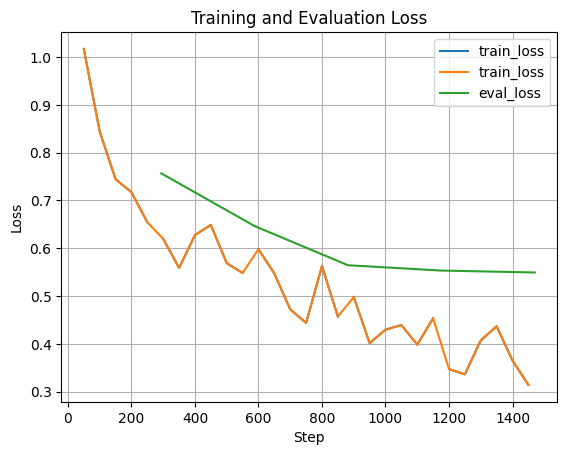

In [ ]:
# Training loss
plt.plot(logs['step'], logs['loss'], label='train_loss')

# Keep only rows where each loss exists
train_logs = logs.dropna(subset=["loss"])
eval_logs  = logs.dropna(subset=["eval_loss"])

plt.plot(train_logs["step"], train_logs["loss"], label="train_loss")
plt.plot(eval_logs["step"], eval_logs["eval_loss"], label="eval_loss")

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training and Evaluation Loss")
plt.legend()
plt.grid()
plt.show()

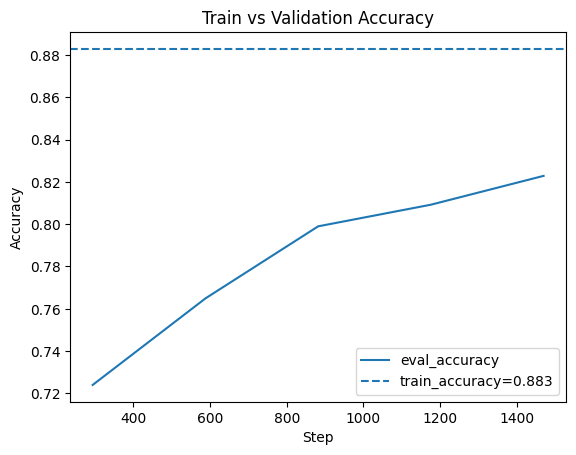

In [ ]:

acc_logs = logs.dropna(subset=["eval_accuracy"])

# Compute training accuracy once (after training)
train_metrics = trainer.evaluate(eval_dataset=train_dataset, metric_key_prefix="train")
train_acc = train_metrics["train_accuracy"]

plt.figure()
plt.plot(acc_logs["step"], acc_logs["eval_accuracy"], label="eval_accuracy")

# horizontal line for train accuracy
plt.axhline(y=train_acc, linestyle="--", label=f"train_accuracy={train_acc:.3f}")

plt.xlabel("Step")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy")
plt.legend()
plt.show()